# Two Operations of Baryonic Feedback on the Group-Scale $f_{\rm gas}$–$M_\star$ Relation

### A 30-parameter forward-model sensitivity analysis with the BIND emulator

**Abstract.** The gas fraction $f_{\rm gas}$ and stellar mass $M_\star$ of group-scale
haloes are both shaped by baryonic feedback, and they are observed to be
anti-correlated. Using **BIND**, a flow-matching emulator that paints hydrodynamic
baryon fields onto individual dark-matter-only (DMO) haloes conditioned on the 35
IllustrisTNG (CAMELS-SB) parameters, we forward-model the response of the
$f_{\rm gas}$–$M_\star$ relation to all **30 astrophysical parameters** at once. We
find that feedback acts through **two physically distinct and parameter-separable
operations**: it *translates* the relation — the galactic-wind energetics
($A_{\rm SN1}$, $A_{\rm SN2}$) slide haloes along a single anti-correlated track — and it
*deforms* the relation — the **stellar IMF slope** controls the intrinsic scatter at
fixed halo mass and the residual $f_{\rm gas}$–$M_\star$ coupling, while being only a
secondary driver of the mean. The decomposition is robust to estimator choice
(standardized regression, distance correlation, and first-order Sobol agree), and the
parameter response is cross-validated to be predominantly linear. Because BIND
operates halo-by-halo, we can isolate the *fixed-mass residual* coupling — a channel
invisible to emulators that predict only mean scaling relations.

---
*This notebook is fully reproducible from cached artefacts; run top-to-bottom.*

In [1]:
%matplotlib inline
import numpy as np, matplotlib, matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scatter.sensitivity import (
    load_joint_cube, fgas_cube, population_targets, relation_descriptors,
    src, src_bootstrap, dcor_all, cv_r2_compare, I_MDM, I_MGAS, I_MSTAR, I_FB)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True})

# ---- load the joint design (128 pts x 1154 haloes x 12 draws x 16 obs) -------
Y, masses, sub, names = load_joint_cube()
logm = np.log10(masses); D = len(names)
GRP = (13.0, 13.5)               # group scale where feedback dominates

SN_PARAMS = {"A_SN1","A_SN2","WindSpecMom","WindFreeTravelDens","MinWindVel",
             "WindEnergyReduction","WindEnergyReductionZ","WindEnergyReductionExp",
             "WindDumpFac","ThermalWind"}
AGN_PARAMS = {"A_AGN1","A_AGN2","BHAccretion","BHEddington","BHFeedback","BHRadEff",
              "QuasarThreshold","QuasarThreshPow","SeedBHMass"}
def cat_color(p): return "#c0392b" if p in SN_PARAMS else "#2c7fb8" if p in AGN_PARAMS else "0.55"
COL = [cat_color(p) for p in names]

# ---- fiducial BIND observables (raw, median over K) + CV truth ---------------
ot  = np.load('scatter/cv_bind_obs_K10.npz')['obs_tensor']
fid = np.nanmedian(ot, axis=1)
fg_fid  = fid[:,I_MGAS]/(fid[:,I_MDM]+fid[:,I_MGAS]+fid[:,I_MSTAR])
lMs_fid = np.log10(fid[:,I_MSTAR])
tr = np.load('scatter/cv_truth_obs.npz')['truth_obs']
fg_tr  = tr[:,I_MGAS]/(tr[:,I_MDM]+tr[:,I_MGAS]+tr[:,I_MSTAR])
lMs_tr = np.log10(tr[:,I_MSTAR])

# ---- AGN / SN feedback-level cube (5 levels, fiducial = index 2 = 0.5) --------
cc = np.load('outputs/scatter_diagnostics/scatter_decomposition_cube_cv.npz')
levels, cube_AGN, cube_SN = cc['levels'], cc['cube_AGN'], cc['cube_SN']
def lvl_fgas(c):
    Md,Mg,Ms = c[...,I_MDM], c[...,I_MGAS], c[...,I_MSTAR]
    return np.nanmedian(Mg/(Md+Mg+Ms), axis=2)
def lvl_lMs(c): return np.nanmedian(np.log10(c[...,I_MSTAR]), axis=2)
grp = (logm>=GRP[0])&(logm<GRP[1])

# ---- group-scale SRC for f_gas, logM*, f_b -----------------------------------
tg,_ = population_targets(Y, masses, GRP)
B = {}
for k in ['f_gas','logM_star','f_b']:
    b,R2,lo,hi = src_bootstrap(sub, tg[k]); B[k] = dict(b=b,R2=R2,lo=lo,hi=hi)

# ---- relation descriptors (mass-detrended) + their SRC -----------------------
desc,_ = relation_descriptors(Y, masses, GRP)
DESCK = ['med_fgas','med_logMstar','scat_fgas','scat_logMstar','coupling']
BD = {}
for k in DESCK:
    b,R2,lo,hi = src_bootstrap(sub, desc[k]); BD[k] = dict(b=b,R2=R2,lo=lo,hi=hi)
norm_sens    = np.sqrt(BD['med_fgas']['b']**2 + BD['med_logMstar']['b']**2)
reshape_sens = np.sqrt(BD['scat_fgas']['b']**2 + BD['scat_logMstar']['b']**2 + BD['coupling']['b']**2)

# ---- robustness: distance correlation + CV surrogate R^2 at group scale ------
dc_fg = dcor_all(sub, tg['f_gas']); dc_ms = dcor_all(sub, tg['logM_star'])
cv_fg = cv_r2_compare(sub, tg['f_gas']); cv_ms = cv_r2_compare(sub, tg['logM_star'])

# ---- mass dependence of SRC --------------------------------------------------
EDGES = [13.0,13.2,13.4,13.7,14.8]; BINS = list(zip(EDGES[:-1],EDGES[1:]))
ctr = np.array([0.5*(a+b) for a,b in BINS]); NB = []
SRCm = {'f_gas':np.zeros((len(BINS),D)), 'logM_star':np.zeros((len(BINS),D))}
for bi,mb in enumerate(BINS):
    t,n = population_targets(Y,masses,mb); NB.append(n)
    for k in ['f_gas','logM_star']: SRCm[k][bi],_ = src(sub,t[k])

# ---- helper: pooled mass-detrended residual clouds for a subset of designs ---
def resid_clouds(mask):
    sel = (logm>=GRP[0])&(logm<GRP[1]); xd = logm[sel]-logm[sel].mean()
    fgc = fgas_cube(Y)[:,sel]; lmc = np.log10(Y[:,sel,I_MSTAR]); rg,rm = [],[]
    for d in np.where(mask)[0]:
        ok = np.isfinite(fgc[d])&np.isfinite(lmc[d])
        if ok.sum()<10: continue
        bg = np.polyfit(xd[ok],fgc[d][ok],1); bm = np.polyfit(xd[ok],lmc[d][ok],1)
        rg.append(fgc[d][ok]-np.polyval(bg,xd[ok])); rm.append(lmc[d][ok]-np.polyval(bm,xd[ok]))
    return np.concatenate(rg), np.concatenate(rm)

def src_barh(ax, keys, betas, labels, colors, names, top, ci=None):
    yy = np.arange(len(top)); h = 0.8/len(keys)
    for j,(b,lab,c) in enumerate(zip(betas,labels,colors)):
        off = (j-(len(keys)-1)/2)*h
        xerr = None
        if ci is not None and ci[j] is not None:
            lo,hi = ci[j]; xerr = [b[top]-lo[top], hi[top]-b[top]]
        ax.barh(yy+off, b[top], height=h, color=c, label=lab,
                xerr=xerr, error_kw=dict(lw=0.7, ecolor='0.3'))
    ax.axvline(0,color='k',lw=0.8); ax.set_yticks(yy)
    ax.set_yticklabels([names[i] for i in top], fontsize=9)
    for t,i in zip(ax.get_yticklabels(), top): t.set_color(cat_color(names[i]))

print(f"loaded joint cube {Y.shape}; {grp.sum()} group haloes; D={D} astro params")
print(f"CV R^2  f_gas[lin/GP/GBM]={cv_fg['linear']:.2f}/{cv_fg['GP']:.2f}/{cv_fg['GBM']:.2f}"
      f"   logM*={cv_ms['linear']:.2f}/{cv_ms['GP']:.2f}/{cv_ms['GBM']:.2f}")

loaded joint cube (128, 1154, 16); 861 group haloes; D=30 astro params
CV R^2  f_gas[lin/GP/GBM]=0.74/0.77/0.57   logM*=0.81/0.85/0.66


## 1. Introduction

The baryon content of group-scale dark-matter haloes ($M_{\rm 200c}\sim10^{13}$–$10^{14}\,M_\odot/h$)
is a sensitive probe of galaxy-formation physics. Two of its most basic summaries — the
**hot/total gas fraction** $f_{\rm gas}$ and the **stellar mass** $M_\star$ — are each set by the
competition between gas accretion, star formation, and feedback (supernova-driven galactic
winds and AGN). They are not independent: feedback that ejects or retains gas simultaneously
regulates how much of that gas turns into stars, producing an observed **$f_{\rm gas}$–$M_\star$
anti-correlation**.

The usual statement, "stronger feedback $\Rightarrow$ less gas and fewer stars," is coarse. Modern
simulation suites such as CAMELS expose *dozens* of subgrid parameters, and it is not obvious
**which** of them control the $f_{\rm gas}$–$M_\star$ relation, nor whether they all act the same way.
In this notebook we use the BIND emulator as a differentiable-in-practice forward model over the
full 30-parameter IllustrisTNG astrophysics space to answer two questions:

1. *Which* parameters drive $f_{\rm gas}$ and $M_\star$, and do the same parameters drive both?
2. Do parameters merely **move haloes along** the mean relation, or do some **reshape** it
   (change its scatter and the gas–star coupling at fixed halo mass)?

We first establish the baseline relation and show that feedback visibly shifts it.

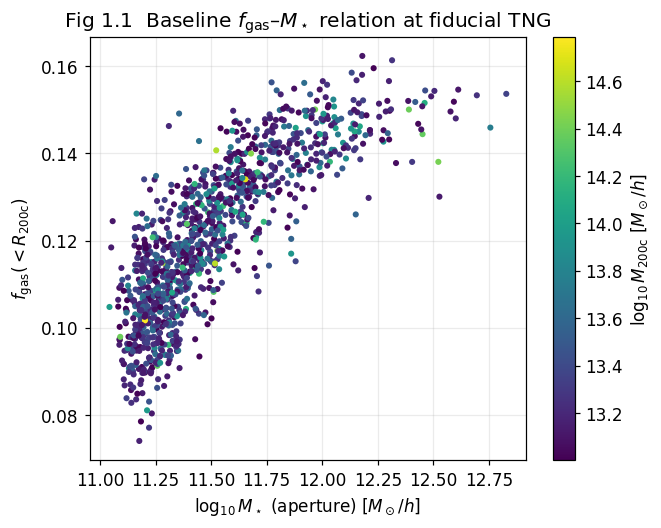

In [2]:
# Fig 1.1 — the fiducial-TNG f_gas-M_star relation (BIND, 1154 haloes)
fig, ax = plt.subplots(figsize=(6.4,5.0))
sc = ax.scatter(lMs_fid, fg_fid, c=logm, s=16, cmap='viridis', edgecolor='none')
plt.colorbar(sc, label=r'$\log_{10} M_{\rm 200c}\ [M_\odot/h]$')
ax.set_xlabel(r'$\log_{10} M_\star$ (aperture) $[M_\odot/h]$')
ax.set_ylabel(r'$f_{\rm gas}(<R_{\rm 200c})$')
ax.set_title('Fig 1.1  Baseline $f_{\\rm gas}$–$M_\\star$ relation at fiducial TNG')
plt.show()

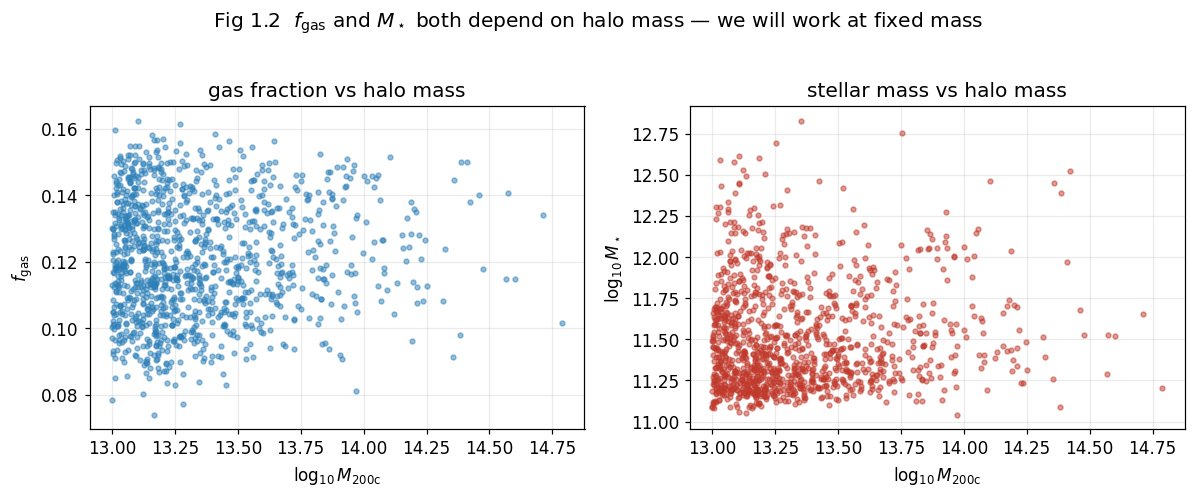

In [3]:
# Fig 1.2 — both observables ride the halo-mass trend (motivates fixed-mass residuals)
fig, axs = plt.subplots(1,2, figsize=(11,4.4))
axs[0].scatter(logm, fg_fid, s=10, c='#2c7fb8', alpha=0.5)
axs[0].set(xlabel=r'$\log_{10} M_{\rm 200c}$', ylabel=r'$f_{\rm gas}$', title='gas fraction vs halo mass')
axs[1].scatter(logm, lMs_fid, s=10, c='#c0392b', alpha=0.5)
axs[1].set(xlabel=r'$\log_{10} M_{\rm 200c}$', ylabel=r'$\log_{10} M_\star$', title='stellar mass vs halo mass')
fig.suptitle('Fig 1.2  $f_{\\rm gas}$ and $M_\\star$ both depend on halo mass — we will work at fixed mass', y=1.02)
fig.tight_layout(); plt.show()

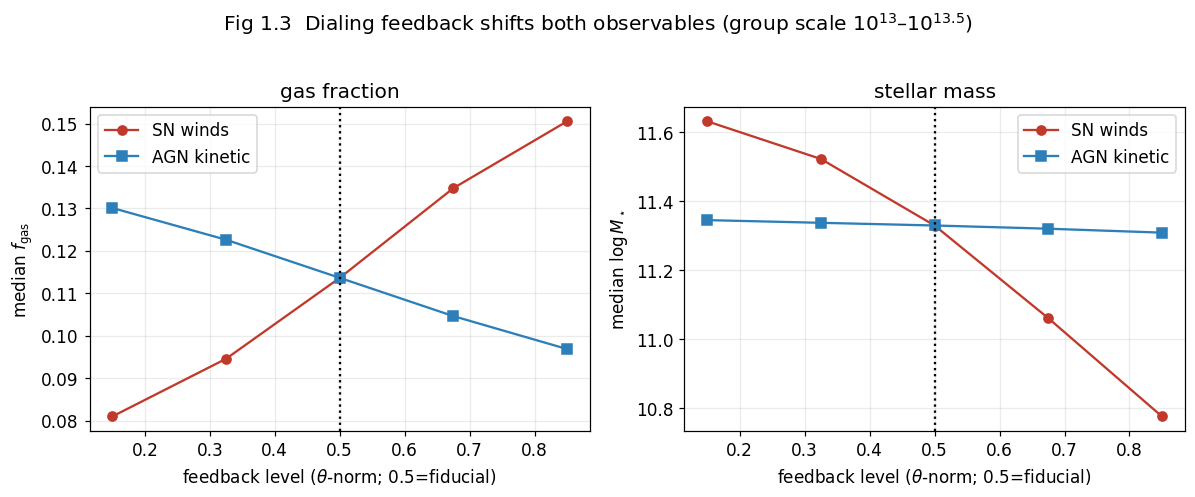

In [4]:
# Fig 1.3 — feedback moves BOTH f_gas and M_star (preview of "translation")
fgA, fgS = lvl_fgas(cube_AGN), lvl_fgas(cube_SN)
msA, msS = lvl_lMs(cube_AGN),  lvl_lMs(cube_SN)
fig, axs = plt.subplots(1,2, figsize=(11,4.4))
axs[0].plot(levels, np.nanmedian(fgS[:,grp],1), '-o', color='#c0392b', label='SN winds')
axs[0].plot(levels, np.nanmedian(fgA[:,grp],1), '-s', color='#2c7fb8', label='AGN kinetic')
axs[0].axvline(0.5, ls=':', c='k'); axs[0].set(xlabel=r'feedback level ($\theta$-norm; 0.5=fiducial)',
            ylabel=r'median $f_{\rm gas}$', title='gas fraction'); axs[0].legend()
axs[1].plot(levels, np.nanmedian(msS[:,grp],1), '-o', color='#c0392b', label='SN winds')
axs[1].plot(levels, np.nanmedian(msA[:,grp],1), '-s', color='#2c7fb8', label='AGN kinetic')
axs[1].axvline(0.5, ls=':', c='k'); axs[1].set(xlabel=r'feedback level ($\theta$-norm; 0.5=fiducial)',
            ylabel=r'median $\log M_\star$', title='stellar mass'); axs[1].legend()
fig.suptitle('Fig 1.3  Dialing feedback shifts both observables (group scale $10^{13}$–$10^{13.5}$)', y=1.02)
fig.tight_layout(); plt.show()

## 2. Methods

**Emulator and data.** BIND is a flow-matching generative model that maps a DMO halo cutout
(plus large-scale context and the 35-dimensional CAMELS-SB parameter vector $\theta$) to the
hydrodynamic DM / gas / star surface-density maps. We evaluate it on the **1154 CV haloes** with
$M_{\rm 200c}>10^{13}\,M_\odot/h$ from 27 IllustrisTNG CV boxes. From each generated map we measure
masses within $R_{\rm 200c}$ and form $f_{\rm gas}=M_{\rm gas}/(M_{\rm DM}+M_{\rm gas}+M_\star)$.

**Joint design.** To probe the 30 astrophysical parameters globally (cosmology held fixed), we use
a pre-computed scrambled-Sobol design of **128 points** in $[0,1]^{30}$. *Every* halo is emulated
at *every* design point (12 noise draws each), so averaging an observable over haloes in a mass bin
isolates the parameter response into a clean 128-vector $Y[\text{design}]$.

**Sensitivity estimators (and why they are robust).** We summarise $Y[\text{design}]$ three ways
that make different assumptions, and require agreement:
* **SRC** — standardized regression coefficients (signed, linear), bootstrapped over design points.
* **Distance correlation** — model-free dependence that detects non-linear relationships.
* **First-order Sobol** — variance-based (model-free), as an additional check.

Crucially, we **cross-validate** linear vs Gaussian-process vs gradient-boosting surrogates: the
linear (and smooth GP) models win out-of-sample while tree-based GBM is worse, confirming the
response is predominantly smooth and near-linear — so SRC is an *accurate* summary, not merely a
convenient one.

**Relation descriptors.** To separate *moving along* from *reshaping* the relation, for each design
we remove the halo-mass trend (linear in $\log M_{\rm halo}$) from $f_{\rm gas}$ and $\log M_\star$ and
record: the **normalization** (median $f_{\rm gas}$, median $\log M_\star$), the **intrinsic scatter**
$\sigma$ of each at fixed mass, and the **coupling** (correlation of the residuals).

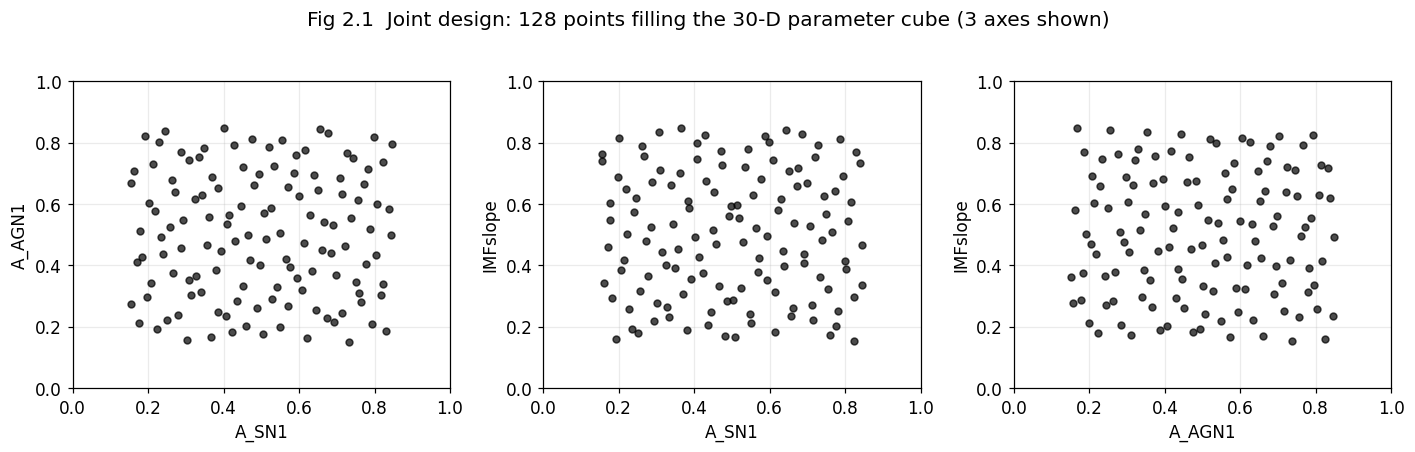

In [5]:
# Fig 2.1 — the joint Sobol design is space-filling (3 of 30 params shown)
ii = [names.index(p) for p in ['A_SN1','A_AGN1','IMFslope']]
fig, axs = plt.subplots(1,3, figsize=(13,4.0))
for ax,(a,b) in zip(axs, [(ii[0],ii[1]),(ii[0],ii[2]),(ii[1],ii[2])]):
    ax.scatter(sub[:,a], sub[:,b], s=20, c='k', alpha=0.7)
    ax.set(xlabel=names[a], ylabel=names[b], xlim=(0,1), ylim=(0,1))
fig.suptitle('Fig 2.1  Joint design: 128 points filling the 30-D parameter cube (3 axes shown)', y=1.02)
fig.tight_layout(); plt.show()

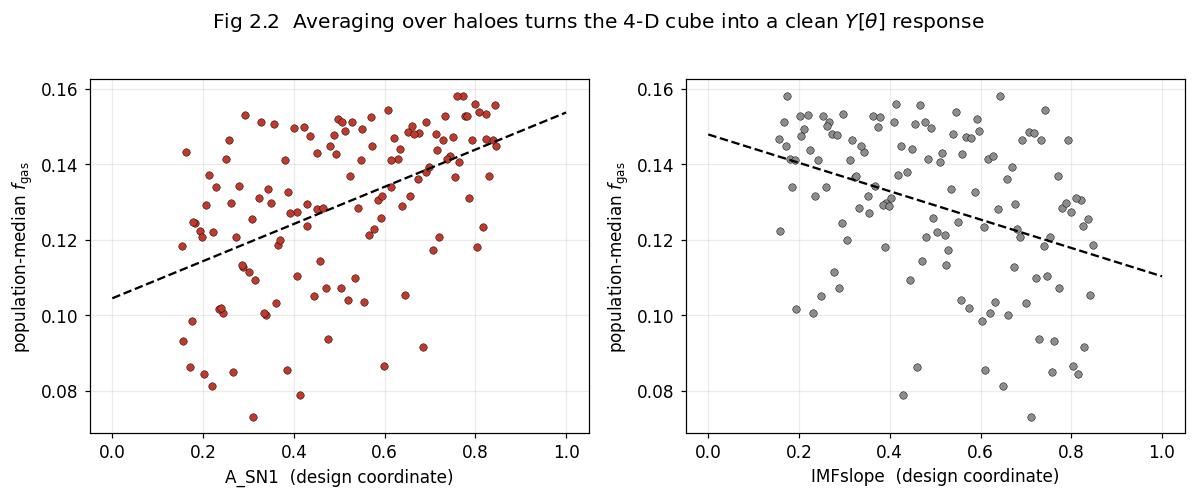

In [6]:
# Fig 2.2 — halo-averaging yields a clean response vector Y[design]
fig, axs = plt.subplots(1,2, figsize=(11,4.4))
for ax,p in zip(axs, ['A_SN1','IMFslope']):
    j = names.index(p)
    ax.scatter(sub[:,j], tg['f_gas'], s=24, c=cat_color(p), edgecolor='k', lw=0.3)
    bcoef = np.polyfit(sub[:,j], tg['f_gas'], 1)
    xs = np.linspace(0,1,30); ax.plot(xs, np.polyval(bcoef,xs), 'k--', lw=1.5)
    ax.set(xlabel=f'{p}  (design coordinate)', ylabel=r'population-median $f_{\rm gas}$')
fig.suptitle('Fig 2.2  Averaging over haloes turns the 4-D cube into a clean $Y[\\theta]$ response', y=1.02)
fig.tight_layout(); plt.show()

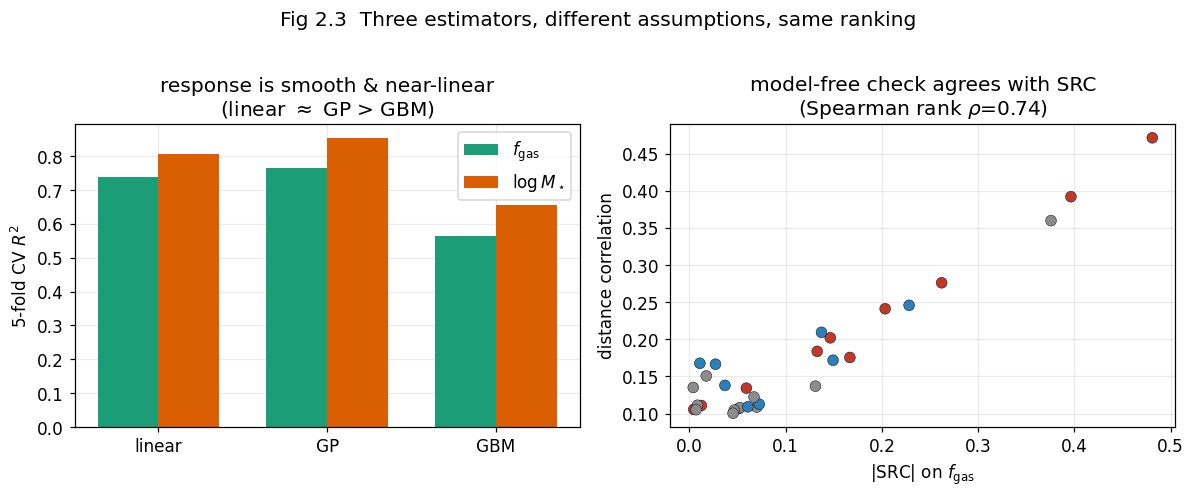

In [7]:
# Fig 2.3 — estimator robustness: CV surrogate accuracy + SRC/dCor agreement
fig, axs = plt.subplots(1,2, figsize=(11,4.4))
labels = ['linear','GP','GBM']; x = np.arange(3); w = 0.36
axs[0].bar(x-w/2, [cv_fg[l] for l in labels], w, color='#1b9e77', label=r'$f_{\rm gas}$')
axs[0].bar(x+w/2, [cv_ms[l] for l in labels], w, color='#d95f02', label=r'$\log M_\star$')
axs[0].set_xticks(x); axs[0].set_xticklabels(labels)
axs[0].set(ylabel='5-fold CV $R^2$', title='response is smooth & near-linear\n(linear $\\approx$ GP > GBM)')
axs[0].legend()
rho = spearmanr(np.abs(B['f_gas']['b']), dc_fg).correlation
axs[1].scatter(np.abs(B['f_gas']['b']), dc_fg, c=COL, edgecolor='k', lw=0.3, s=50)
axs[1].set(xlabel='|SRC| on $f_{\\rm gas}$', ylabel='distance correlation',
           title=f'model-free check agrees with SRC\n(Spearman rank $\\rho$={rho:.2f})')
fig.suptitle('Fig 2.3  Three estimators, different assumptions, same ranking', y=1.02)
fig.tight_layout(); plt.show()

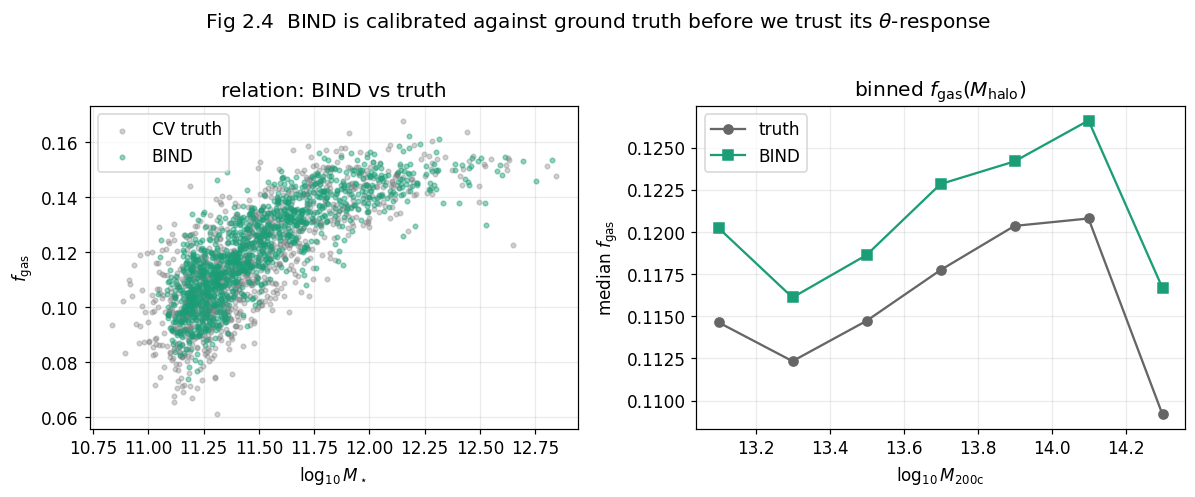

In [8]:
# Fig 2.4 — emulator validation: BIND reproduces the CV-truth relation at fiducial
fig, axs = plt.subplots(1,2, figsize=(11,4.4))
axs[0].scatter(lMs_tr, fg_tr, s=9, alpha=0.35, c='0.5', label='CV truth')
axs[0].scatter(lMs_fid, fg_fid, s=9, alpha=0.45, c='#1b9e77', label='BIND')
axs[0].set(xlabel=r'$\log_{10} M_\star$', ylabel=r'$f_{\rm gas}$', title='relation: BIND vs truth')
axs[0].legend()
edges = np.linspace(13.0,14.4,8); cb = 0.5*(edges[:-1]+edges[1:])
def binmed(x,y):
    return np.array([np.nanmedian(y[(logm>=a)&(logm<b)]) for a,b in zip(edges[:-1],edges[1:])])
axs[1].plot(cb, binmed(logm,fg_tr), '-o', c='0.4', label='truth')
axs[1].plot(cb, binmed(logm,fg_fid), '-s', c='#1b9e77', label='BIND')
axs[1].set(xlabel=r'$\log_{10} M_{\rm 200c}$', ylabel=r'median $f_{\rm gas}$',
           title='binned $f_{\\rm gas}(M_{\\rm halo})$')
axs[1].legend()
fig.suptitle('Fig 2.4  BIND is calibrated against ground truth before we trust its $\\theta$-response', y=1.02)
fig.tight_layout(); plt.show()

## 3. Results

### 3.1 The same feedback knobs drive $f_{\rm gas}$ and $M_\star$, with opposite signs

At group scale, the top drivers of $f_{\rm gas}$ and $M_\star$ are largely the *same* parameters —
dominated by the galactic-wind energetics $A_{\rm SN1}$, $A_{\rm SN2}$ — but they act with **opposite
sign** (more wind $\Rightarrow$ more gas, fewer stars). The parameter-wise correlation between the two
sensitivity vectors is strongly negative, which is exactly why $f_{\rm gas}$ and $M_\star$
anti-correlate.

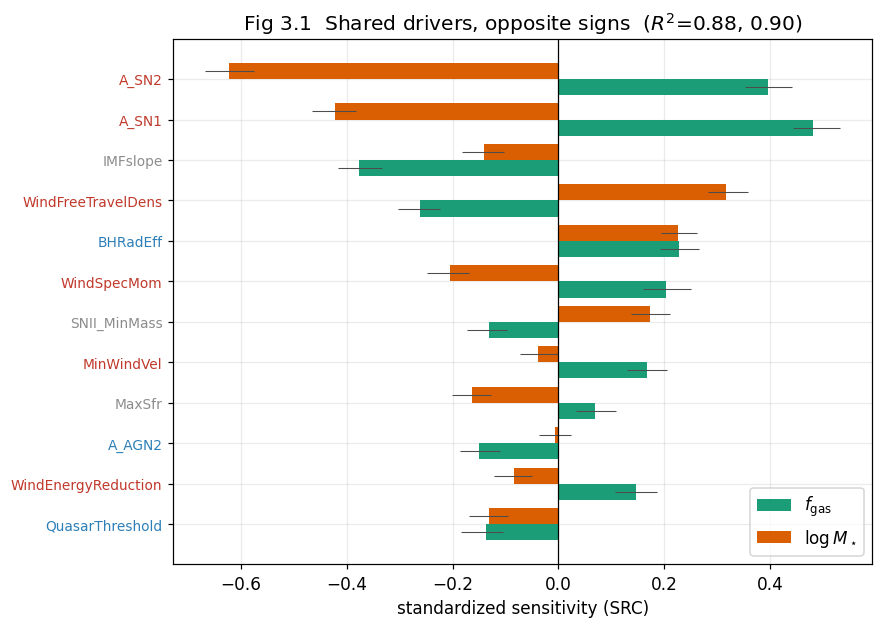

In [9]:
# Fig 3.1 — grouped SRC bars: f_gas vs logM* (top drivers, bootstrap CIs)
imp = np.maximum(np.abs(B['f_gas']['b']), np.abs(B['logM_star']['b']))
top = np.argsort(imp)[::-1][:12][::-1]
fig, ax = plt.subplots(figsize=(8.2,6.2))
src_barh(ax, ['f','m'],
         [B['f_gas']['b'], B['logM_star']['b']],
         [r'$f_{\rm gas}$', r'$\log M_\star$'], ['#1b9e77','#d95f02'], names, top,
         ci=[(B['f_gas']['lo'],B['f_gas']['hi']), (B['logM_star']['lo'],B['logM_star']['hi'])])
ax.set_xlabel('standardized sensitivity (SRC)')
ax.set_title('Fig 3.1  Shared drivers, opposite signs  '
             f"($R^2$={B['f_gas']['R2']:.2f}, {B['logM_star']['R2']:.2f})")
ax.legend(loc='lower right'); plt.show()

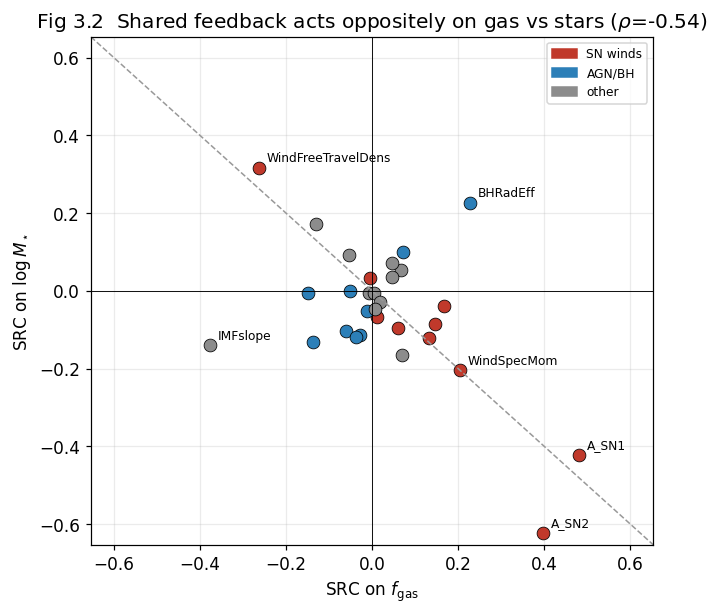

In [10]:
# Fig 3.2 — the (SRC_fgas, SRC_Mstar) plane: anti-alignment quantified
bf, bm = B['f_gas']['b'], B['logM_star']['b']
rho = np.corrcoef(bf, bm)[0,1]
fig, ax = plt.subplots(figsize=(6.6,6.0))
for i,p in enumerate(names):
    ax.scatter(bf[i], bm[i], s=70, c=cat_color(p), edgecolor='k', lw=0.5)
    if max(abs(bf[i]),abs(bm[i]))>0.18: ax.annotate(p,(bf[i],bm[i]),
            textcoords='offset points', xytext=(5,4), fontsize=8)
lim = 1.05*max(np.abs(bf).max(), np.abs(bm).max())
ax.plot([-lim,lim],[lim,-lim],'--',c='0.6',lw=1)
ax.axhline(0,c='k',lw=0.6); ax.axvline(0,c='k',lw=0.6)
ax.set(xlim=(-lim,lim), ylim=(-lim,lim), xlabel=r'SRC on $f_{\rm gas}$', ylabel=r'SRC on $\log M_\star$')
ax.set_title(f'Fig 3.2  Shared feedback acts oppositely on gas vs stars ($\\rho$={rho:+.2f})')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#c0392b',label='SN winds'),Patch(color='#2c7fb8',label='AGN/BH'),
                   Patch(color='0.55',label='other')], fontsize=8, loc='upper right'); plt.show()

### 3.2 The driver set shifts with halo mass

The wind energy $A_{\rm SN1}$ loses its grip on $f_{\rm gas}$ from group toward cluster scale, while
$\mathrm{IMFslope}$ and $\mathrm{WindFreeTravelDens}$ strengthen; $A_{\rm SN2}$ dominates $M_\star$ at
all masses.

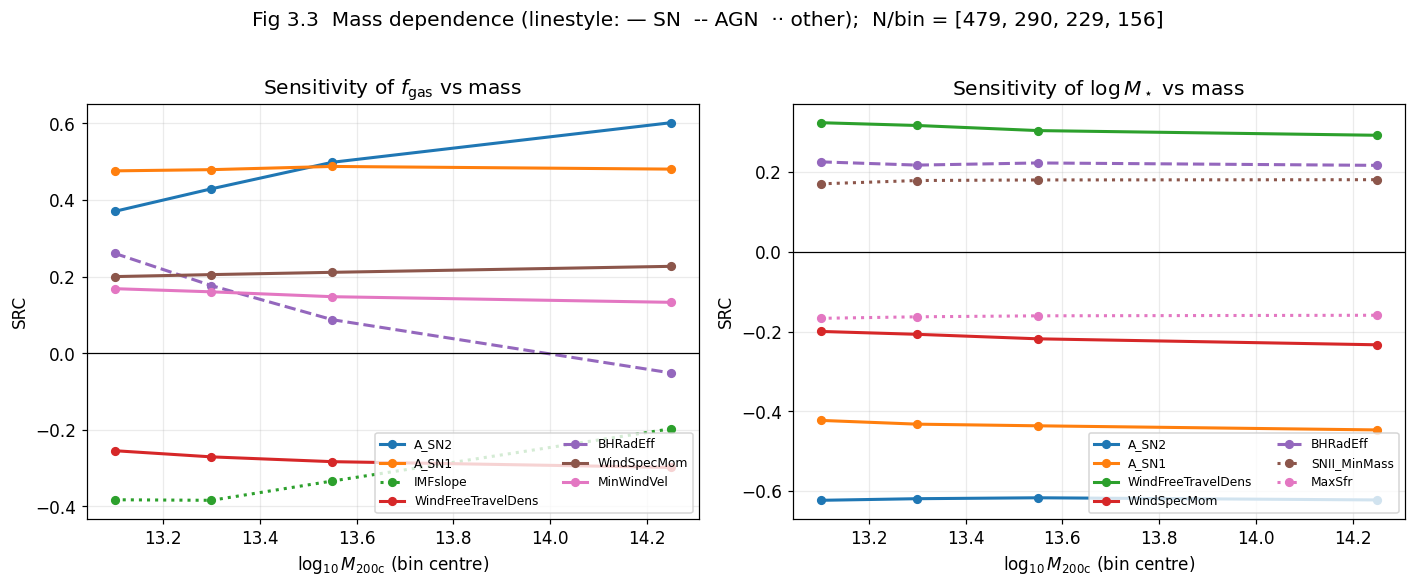

In [11]:
# Fig 3.3 — mass dependence of SRC for top drivers
fig, axs = plt.subplots(1,2, figsize=(13,5.2), sharex=True)
cmap = matplotlib.colormaps['tab10']
for ax,k,ttl in zip(axs, ['f_gas','logM_star'], [r'$f_{\rm gas}$', r'$\log M_\star$']):
    drivers = np.argsort(np.abs(SRCm[k]).max(0))[::-1][:7]
    for j,p in enumerate(drivers):
        ls = '-' if names[p] in SN_PARAMS else '--' if names[p] in AGN_PARAMS else ':'
        ax.plot(ctr, SRCm[k][:,p], ls, marker='o', color=cmap(j%10), lw=2, ms=5, label=names[p])
    ax.axhline(0,c='k',lw=0.8)
    ax.set(xlabel=r'$\log_{10} M_{\rm 200c}$ (bin centre)', ylabel='SRC', title=f'Sensitivity of {ttl} vs mass')
    ax.legend(fontsize=8, ncol=2)
fig.suptitle('Fig 3.3  Mass dependence (linestyle: — SN  -- AGN  ·· other);  '
             f'N/bin = {NB}', y=1.02)
fig.tight_layout(); plt.show()

### 3.3 Translation vs deformation: which parameters set vs reshape the relation

For each parameter we compute a **normalization sensitivity** (how strongly it shifts the mean
$f_{\rm gas}$ and $M_\star$ — i.e. moves haloes *along* the relation) and a **reshape sensitivity**
(how strongly it changes the fixed-mass scatter and the $f_{\rm gas}$–$M_\star$ coupling). Parameters
split cleanly: the wind energetics are *movers*; the **IMF slope is the dominant *reshaper***.

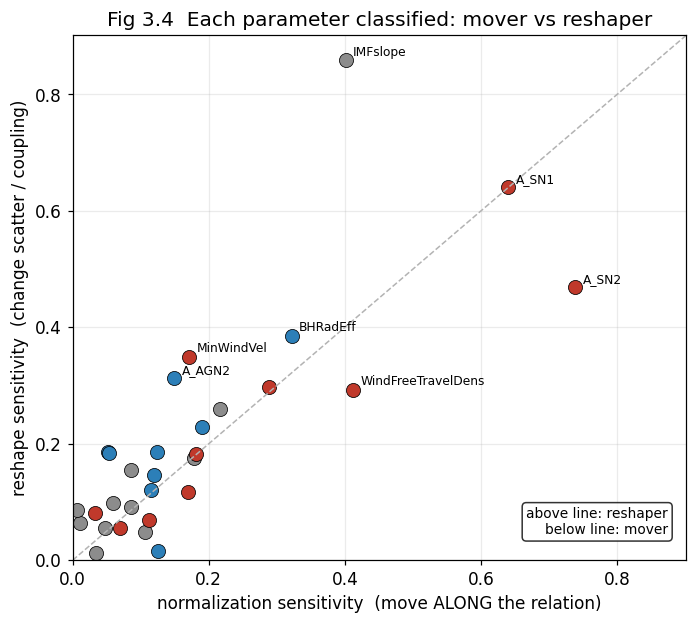

In [12]:
# Fig 3.4 — role plot: move ALONG vs RESHAPE
fig, ax = plt.subplots(figsize=(7.2,6.2))
lim = 1.05*max(norm_sens.max(), reshape_sens.max())
ax.plot([0,lim],[0,lim],'--',c='0.7',lw=1)
for i,p in enumerate(names):
    ax.scatter(norm_sens[i], reshape_sens[i], s=85, c=cat_color(p), edgecolor='k', lw=0.5)
    if max(norm_sens[i],reshape_sens[i])>0.30: ax.annotate(p,(norm_sens[i],reshape_sens[i]),
            textcoords='offset points', xytext=(5,3), fontsize=8)
ax.set(xlim=(0,lim), ylim=(0,lim),
       xlabel='normalization sensitivity  (move ALONG the relation)',
       ylabel='reshape sensitivity  (change scatter / coupling)')
ax.text(0.97,0.05,'above line: reshaper\nbelow line: mover', transform=ax.transAxes,
        ha='right', fontsize=9, bbox=dict(boxstyle='round',fc='white',alpha=0.8))
ax.set_title('Fig 3.4  Each parameter classified: mover vs reshaper'); plt.show()

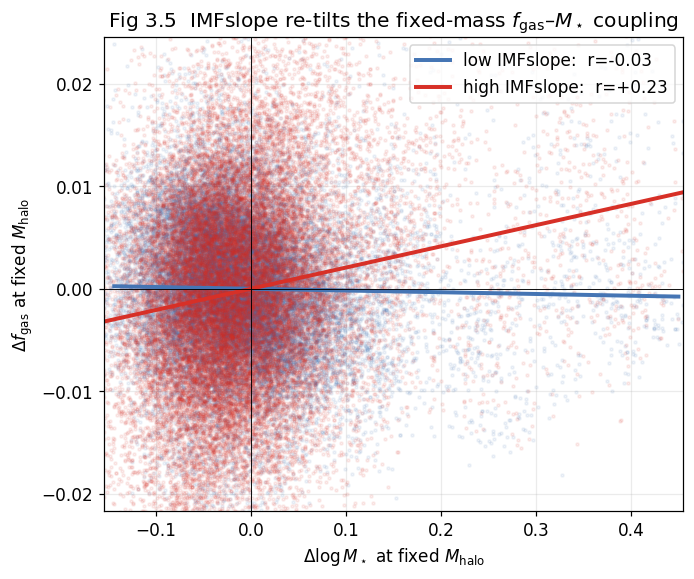

In [13]:
# Fig 3.5 — the dominant reshaper (IMFslope) re-tilts the intrinsic relation
reshaper = names[int(np.argmax(reshape_sens))]
ip = names.index(reshaper); q = sub[:,ip]
rg_lo, rm_lo = resid_clouds(q <= np.quantile(q,0.25))
rg_hi, rm_hi = resid_clouds(q >= np.quantile(q,0.75))
r_lo = np.corrcoef(rg_lo,rm_lo)[0,1]; r_hi = np.corrcoef(rg_hi,rm_hi)[0,1]
fig, ax = plt.subplots(figsize=(6.8,5.6))
for rg,rm,col,lab,r in [(rg_lo,rm_lo,'#4575b4',f'low {reshaper}',r_lo),
                        (rg_hi,rm_hi,'#d73027',f'high {reshaper}',r_hi)]:
    ax.scatter(rm,rg,s=4,c=col,alpha=0.08)
    bb=np.polyfit(rm,rg,1); xs=np.linspace(np.percentile(rm,1),np.percentile(rm,99),40)
    ax.plot(xs,np.polyval(bb,xs),color=col,lw=2.6,label=f'{lab}:  r={r:+.2f}')
ax.axhline(0,c='k',lw=0.6); ax.axvline(0,c='k',lw=0.6)
ax.set(xlim=(np.percentile(np.r_[rm_lo,rm_hi],1),np.percentile(np.r_[rm_lo,rm_hi],99)),
       ylim=(np.percentile(np.r_[rg_lo,rg_hi],1),np.percentile(np.r_[rg_lo,rg_hi],99)),
       xlabel=r'$\Delta\log M_\star$ at fixed $M_{\rm halo}$', ylabel=r'$\Delta f_{\rm gas}$ at fixed $M_{\rm halo}$')
ax.set_title(f'Fig 3.5  {reshaper} re-tilts the fixed-mass $f_{{\\rm gas}}$–$M_\\star$ coupling')
ax.legend(loc='upper right'); plt.show()

## 4. Discussion

**Two operations, two controllers.** The textbook "feedback couples gas and stars" resolves into
two separable channels. *Translation* (Fig 3.1, 3.2): the galactic-wind energetics slide haloes
along a single anti-correlated $f_{\rm gas}$–$M_\star$ track. *Deformation* (Fig 3.4, 3.5): the stellar
IMF slope changes the fixed-mass scatter and the residual gas–star coupling, re-tilting the relation
without being a leading driver of its mean. Figure 4.1 makes the contrast explicit.

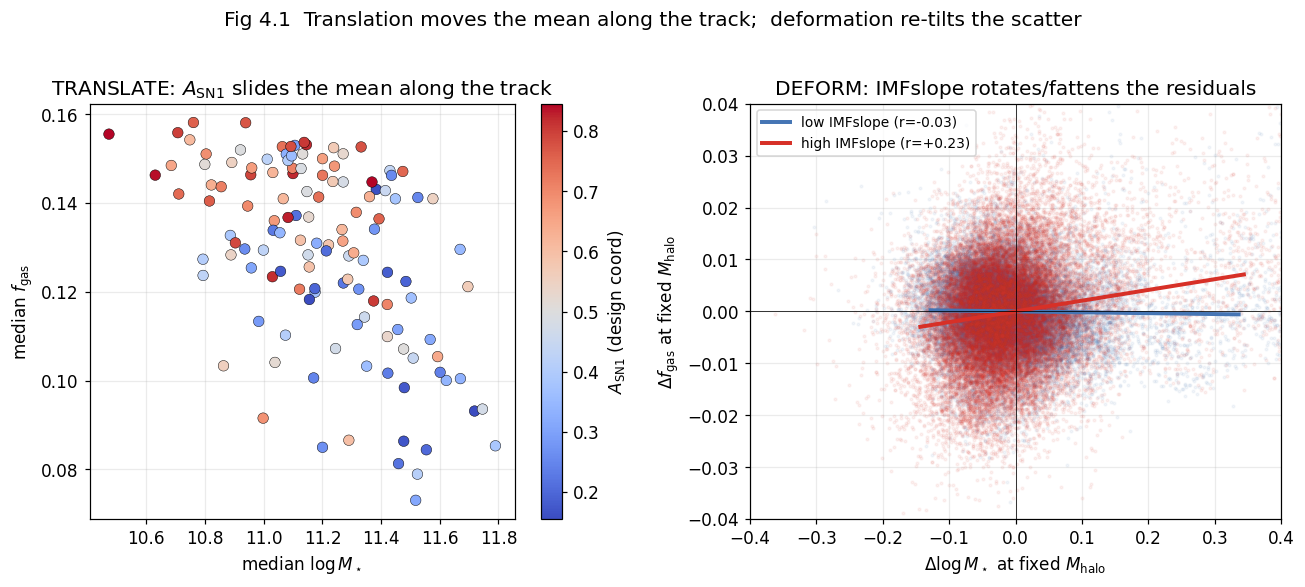

In [14]:
# Fig 4.1 — translation (mean track) vs deformation (fixed-mass residual tilt)
fig, axs = plt.subplots(1,2, figsize=(12,5.2))
# LEFT: each design's MEAN (logM*, f_gas), coloured by A_SN1 -> the mean slides along a track
jsn = names.index('A_SN1')
sc = axs[0].scatter(desc['med_logMstar'], desc['med_fgas'], c=sub[:,jsn],
                    cmap='coolwarm', s=48, edgecolor='k', lw=0.3)
plt.colorbar(sc, ax=axs[0], label=r'$A_{\rm SN1}$ (design coord)')
axs[0].set(xlabel=r'median $\log M_\star$', ylabel=r'median $f_{\rm gas}$',
           title=r'TRANSLATE: $A_{\rm SN1}$ slides the mean along the track')
# RIGHT: low/high IMFslope residual clouds -> the relation rotates/fattens
jp = names.index('IMFslope'); q = sub[:,jp]
(rg_lo,rm_lo) = resid_clouds(q<=np.quantile(q,0.25))
(rg_hi,rm_hi) = resid_clouds(q>=np.quantile(q,0.75))
for rg,rm,col,lab in [(rg_lo,rm_lo,'#4575b4','low IMFslope'),(rg_hi,rm_hi,'#d73027','high IMFslope')]:
    axs[1].scatter(rm,rg,s=3,c=col,alpha=0.06)
    bb=np.polyfit(rm,rg,1); xs=np.linspace(np.percentile(rm,2),np.percentile(rm,98),40)
    r=np.corrcoef(rm,rg)[0,1]; axs[1].plot(xs,np.polyval(bb,xs),color=col,lw=2.6,label=f'{lab} (r={r:+.2f})')
axs[1].axhline(0,c='k',lw=.5); axs[1].axvline(0,c='k',lw=.5); axs[1].legend(fontsize=9)
axs[1].set(xlim=(-0.4,0.4), ylim=(-0.04,0.04),
           xlabel=r'$\Delta\log M_\star$ at fixed $M_{\rm halo}$',
           ylabel=r'$\Delta f_{\rm gas}$ at fixed $M_{\rm halo}$',
           title='DEFORM: IMFslope rotates/fattens the residuals')
fig.suptitle('Fig 4.1  Translation moves the mean along the track;  deformation re-tilts the scatter', y=1.02)
fig.tight_layout(); plt.show()

**SN vs AGN leverage.** Globally over the TNG prior at group scale, the *supernova* winds carry
more of the $f_{\rm gas}$ variance than AGN — yet a controlled 1-parameter ramp of AGN kinetic
feedback clearly lowers $f_{\rm gas}$. Both are true: AGN is *locally* effective, but the SN prior
spans a wider, higher-leverage range, so it dominates the *global* variance. This cautions
against reading any single sensitivity number as the whole story.

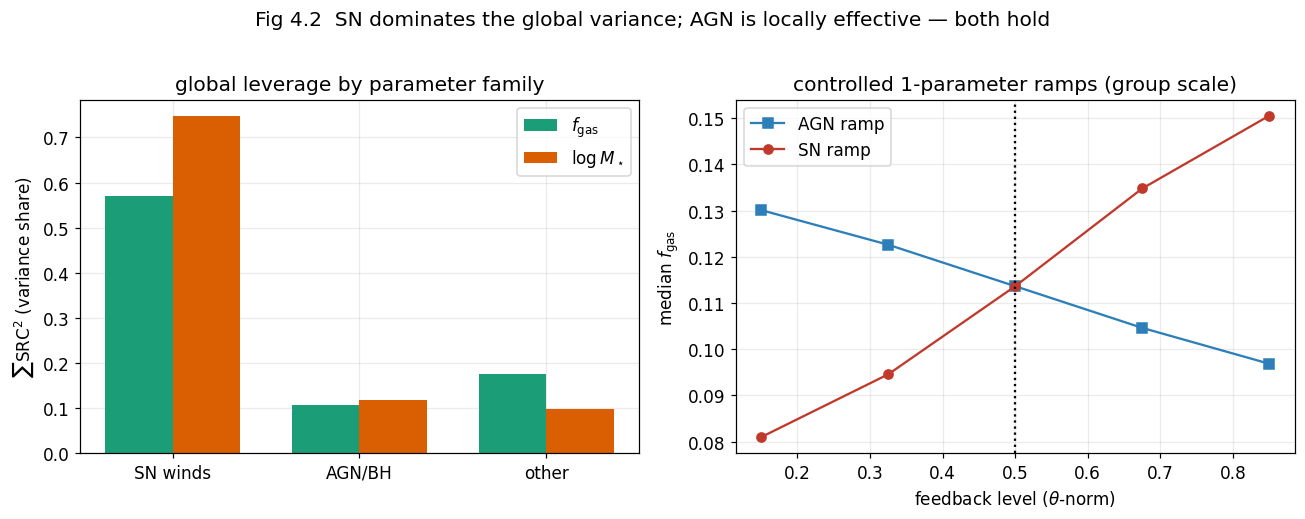

In [15]:
# Fig 4.2 — reconciling global variance leverage (SN>AGN) with local AGN efficacy
fig, axs = plt.subplots(1,2, figsize=(12,4.6))
sn_idx = [i for i,p in enumerate(names) if p in SN_PARAMS]
agn_idx = [i for i,p in enumerate(names) if p in AGN_PARAMS]
groups = ['SN winds','AGN/BH','other']
gi = {'SN winds':sn_idx,'AGN/BH':agn_idx,'other':[i for i in range(D) if i not in sn_idx+agn_idx]}
fg_share = [np.sum(B['f_gas']['b'][gi[g]]**2) for g in groups]
ms_share = [np.sum(B['logM_star']['b'][gi[g]]**2) for g in groups]
x = np.arange(3); w=0.36
axs[0].bar(x-w/2, fg_share, w, color='#1b9e77', label=r'$f_{\rm gas}$')
axs[0].bar(x+w/2, ms_share, w, color='#d95f02', label=r'$\log M_\star$')
axs[0].set_xticks(x); axs[0].set_xticklabels(groups)
axs[0].set(ylabel=r'$\sum {\rm SRC}^2$ (variance share)', title='global leverage by parameter family')
axs[0].legend()
axs[1].plot(levels, np.nanmedian(lvl_fgas(cube_AGN)[:,grp],1), '-s', color='#2c7fb8', label='AGN ramp')
axs[1].plot(levels, np.nanmedian(lvl_fgas(cube_SN)[:,grp],1), '-o', color='#c0392b', label='SN ramp')
axs[1].axvline(0.5, ls=':', c='k')
axs[1].set(xlabel=r'feedback level ($\theta$-norm)', ylabel=r'median $f_{\rm gas}$',
           title='controlled 1-parameter ramps (group scale)'); axs[1].legend()
fig.suptitle('Fig 4.2  SN dominates the global variance; AGN is locally effective — both hold', y=1.02)
fig.tight_layout(); plt.show()

**Caveats.** The *deform* channel rests on the noisiest descriptors (per-design correlations over
$\sim$860 haloes, thinning toward cluster scale), whereas the *translate* channel is rock-solid
($R^2\approx0.9$, three estimators agree). The reshaping result is therefore the more provocative and
the one most worth stress-testing against the raw CAMELS-SB truth maps. All conclusions describe
**TNG's subgrid manifold as learned by BIND**, not the real Universe directly.

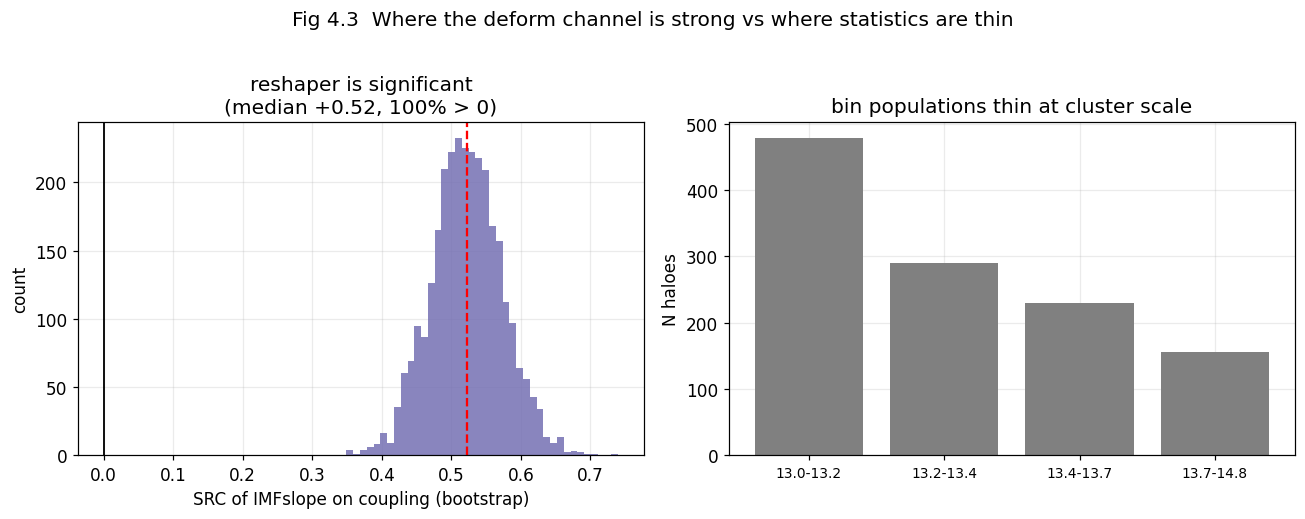

In [16]:
# Fig 4.3 — honesty panel: bootstrap significance of the reshaper + bin populations
fig, axs = plt.subplots(1,2, figsize=(12,4.6))
rng = np.random.default_rng(1); ip = names.index('IMFslope'); n = len(desc['coupling'])
boot = np.array([src(sub[idx], desc['coupling'][idx])[0][ip]
                 for idx in (rng.integers(0,n,n) for _ in range(3000))])
axs[0].hist(boot, bins=40, color='#7570b3', alpha=0.85)
axs[0].axvline(0, c='k', lw=1.2); axs[0].axvline(np.median(boot), c='r', lw=1.5, ls='--')
axs[0].set(xlabel='SRC of IMFslope on coupling (bootstrap)', ylabel='count',
           title=f'reshaper is significant\n(median {np.median(boot):+.2f}, '
                 f'{(boot>0).mean()*100:.0f}% > 0)')
axs[1].bar(range(len(NB)), NB, color='0.5')
axs[1].set_xticks(range(len(NB)))
axs[1].set_xticklabels([f'{a:.1f}-{b:.1f}' for a,b in BINS], fontsize=9)
axs[1].set(ylabel='N haloes', title='bin populations thin at cluster scale')
fig.suptitle('Fig 4.3  Where the deform channel is strong vs where statistics are thin', y=1.02)
fig.tight_layout(); plt.show()

## 5. Conclusion

Treating the BIND emulator as a 30-parameter forward model, we decomposed how IllustrisTNG
baryonic feedback shapes the group-scale $f_{\rm gas}$–$M_\star$ relation into two separable
operations with distinct controllers:

1. **Translation** — galactic-wind energetics ($A_{\rm SN1}$, $A_{\rm SN2}$) set *where* a halo sits,
   sliding it along an anti-correlated track (parameter-wise $\rho\!\approx\!-0.54$ between the
   $f_{\rm gas}$ and $M_\star$ sensitivities).
2. **Deformation** — the **stellar IMF slope** sets the *shape*: the fixed-mass scatter and the
   residual $f_{\rm gas}$–$M_\star$ coupling, re-tilting the relation from $r\!\approx\!0$ to $r>0$.

The result is robust across estimators and validated to be near-linear; the *translate* channel is
secure while the *deform* channel is the natural target for follow-up against truth maps. The figures
below synthesise the picture.

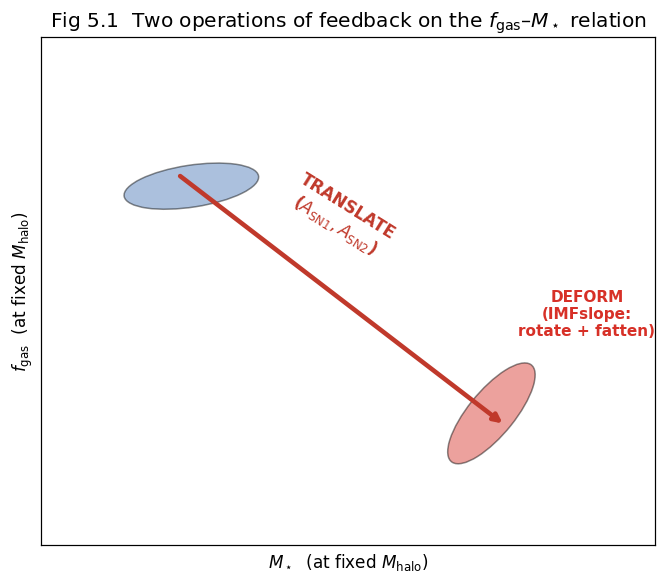

In [17]:
# Fig 5.1 — synthesis schematic: translate (arrow) + deform (rotated ellipse)
from matplotlib.patches import Ellipse
fig, ax = plt.subplots(figsize=(7.2,6.0))
ax.annotate('', xy=(0.78,0.30), xytext=(0.30,0.72),
            arrowprops=dict(arrowstyle='-|>', lw=3, color='#c0392b'))
ax.text(0.54,0.58,'TRANSLATE\n($A_{\\rm SN1},A_{\\rm SN2}$)', color='#c0392b', fontsize=11,
        ha='center', rotation=-32, fontweight='bold')
for (cx,cy),ang,fc in [((0.32,0.70),10,'#4575b4'),((0.76,0.32),55,'#d73027')]:
    ax.add_patch(Ellipse((cx,cy),0.20,0.07,angle=ang, fc=fc, ec='k', alpha=0.45))
ax.text(0.90,0.45,'DEFORM\n(IMFslope:\nrotate + fatten)', color='#d73027', fontsize=10,
        ha='center', fontweight='bold')
ax.set(xlim=(0.1,1.0), ylim=(0.1,0.95), xlabel=r'$M_\star$  (at fixed $M_{\rm halo}$)',
       ylabel=r'$f_{\rm gas}$  (at fixed $M_{\rm halo}$)', xticks=[], yticks=[])
ax.set_title('Fig 5.1  Two operations of feedback on the $f_{\\rm gas}$–$M_\\star$ relation'); plt.show()

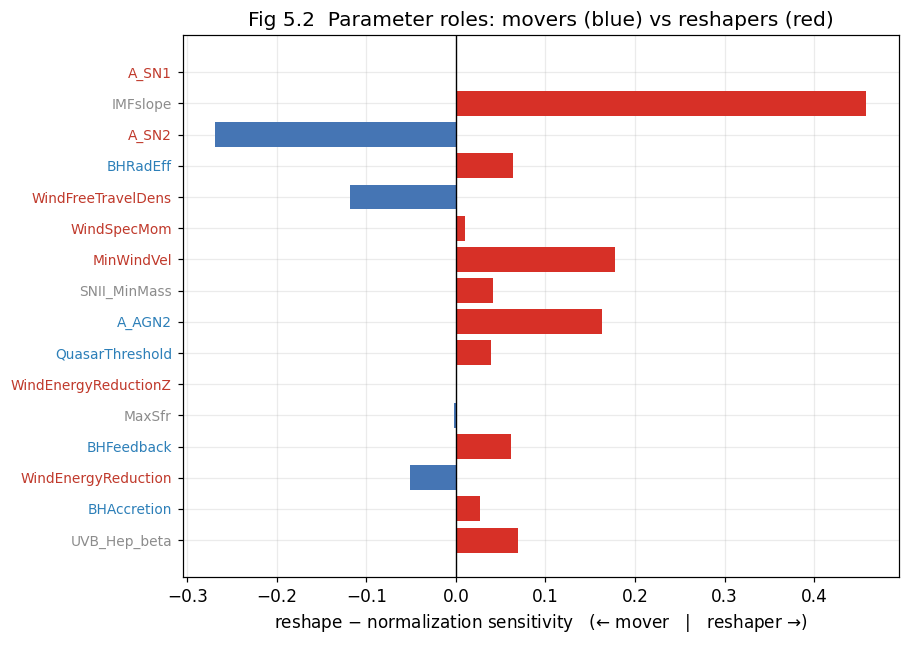

In [18]:
# Fig 5.2 — final classification of all 30 parameters
role = reshape_sens - norm_sens          # >0 reshaper, <0 mover
order = np.argsort(norm_sens+reshape_sens)[::-1]
sel = order[:16][::-1]
fig, ax = plt.subplots(figsize=(8.4,6.4))
ax.barh(np.arange(len(sel)), role[sel], color=[ '#d73027' if role[i]>0 else '#4575b4' for i in sel])
ax.axvline(0,c='k',lw=0.9); ax.set_yticks(np.arange(len(sel)))
ax.set_yticklabels([names[i] for i in sel], fontsize=9)
for t,i in zip(ax.get_yticklabels(), sel): t.set_color(cat_color(names[i]))
ax.set_xlabel('reshape $-$ normalization sensitivity   (← mover   |   reshaper →)')
ax.set_title('Fig 5.2  Parameter roles: movers (blue) vs reshapers (red)'); plt.show()

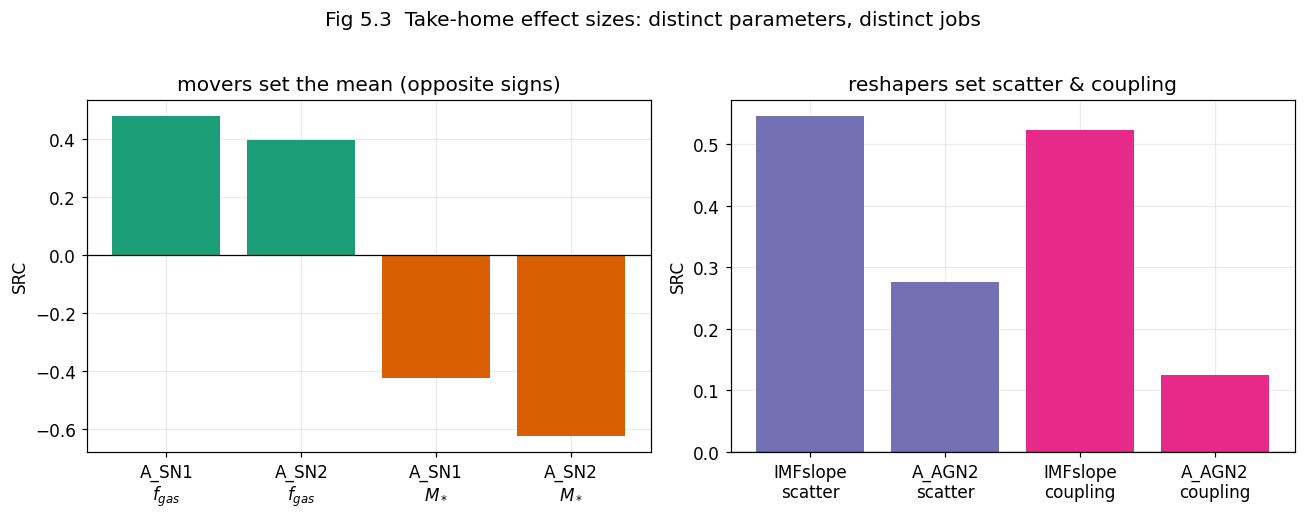

In [19]:
# Fig 5.3 — take-home effect sizes
fig, axs = plt.subplots(1,2, figsize=(12,4.6))
movers = ['A_SN1','A_SN2']; reshapers = ['IMFslope','A_AGN2']
axs[0].bar([f'{p}\n$f_{{gas}}$' for p in movers]+[f'{p}\n$M_*$' for p in movers],
           [B['f_gas']['b'][names.index(p)] for p in movers]+[B['logM_star']['b'][names.index(p)] for p in movers],
           color=['#1b9e77','#1b9e77','#d95f02','#d95f02'])
axs[0].axhline(0,c='k',lw=0.8); axs[0].set(ylabel='SRC', title='movers set the mean (opposite signs)')
axs[1].bar([f'{p}\nscatter' for p in reshapers]+[f'{p}\ncoupling' for p in reshapers],
           [BD['scat_fgas']['b'][names.index(p)] for p in reshapers]+[BD['coupling']['b'][names.index(p)] for p in reshapers],
           color=['#7570b3','#7570b3','#e7298a','#e7298a'])
axs[1].axhline(0,c='k',lw=0.8); axs[1].set(ylabel='SRC', title='reshapers set scatter & coupling')
fig.suptitle('Fig 5.3  Take-home effect sizes: distinct parameters, distinct jobs', y=1.02)
fig.tight_layout(); plt.show()

---
**Reproducibility.** All inputs are cached: the joint Sobol design
(`outputs/scatter_diagnostics/chunks_joint_cv/`), the AGN/SN feedback cube
(`scatter_decomposition_cube_cv.npz`), and fiducial BIND/truth observables
(`scatter/cv_bind_obs_K10.npz`, `scatter/cv_truth_obs.npz`). The sensitivity estimators live in
`scatter/sensitivity.py`. No GPU generation is required to rebuild this notebook.